# CNN with Class Activation Mapping (CAM)

This notebook trains a PyTorch CNN in a style similar to the Class 6 PyTorch implementation, then visualizes **Class Activation Maps** over test images.

### Sample Problem

- Task: CIFAR-10 image classification
- Goal: predict class labels and explain predictions using CAM overlays
- Constraint followed: dataset is downloaded fresh into a new local folder for this notebook

In [1]:
import os
import time
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
from tqdm.notebook import tqdm

In [2]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Hardware-aware settings for local execution
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()
NUM_WORKERS = min(8, os.cpu_count() or 2)
PIN_MEMORY = torch.cuda.is_available()

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

print(f"Device: {DEVICE}")
print(f"Mixed Precision Enabled: {USE_AMP}")
print(f"DataLoader workers: {NUM_WORKERS}")

Device: cuda
Mixed Precision Enabled: True
DataLoader workers: 8


## Download Dataset (Fresh) and Build DataLoaders

This section downloads CIFAR-10 into a timestamped folder so the notebook does not rely on previously downloaded repository data.

In [3]:
# Fresh download directory (new folder each run)
run_tag = time.strftime("%Y%m%d_%H%M%S")
data_root = Path("./runtime_data") / f"cifar10_fresh_{run_tag}"
data_root.mkdir(parents=True, exist_ok=True)

print(f"Fresh dataset path: {data_root.resolve()}")

# CIFAR-10 statistics
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_dataset = torchvision.datasets.CIFAR10(
    root=str(data_root),
    train=True,
    download=True,
    transform=train_transform,
)

test_dataset = torchvision.datasets.CIFAR10(
    root=str(data_root),
    train=False,
    download=True,
    transform=test_transform,
)

class_names = train_dataset.classes
print("Classes:", class_names)
print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")

Fresh dataset path: F:\PhD Stuff\DL Lab\CAMs\runtime_data\cifar10_fresh_20260415_084722


100%|██████████| 170M/170M [00:29<00:00, 5.86MB/s] 
f:\PhD Stuff\DL Lab\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train size: 50000
Test size: 10000


In [4]:
BATCH_SIZE = 256 if torch.cuda.is_available() else 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Batch size: 256
Train batches: 196
Test batches: 40


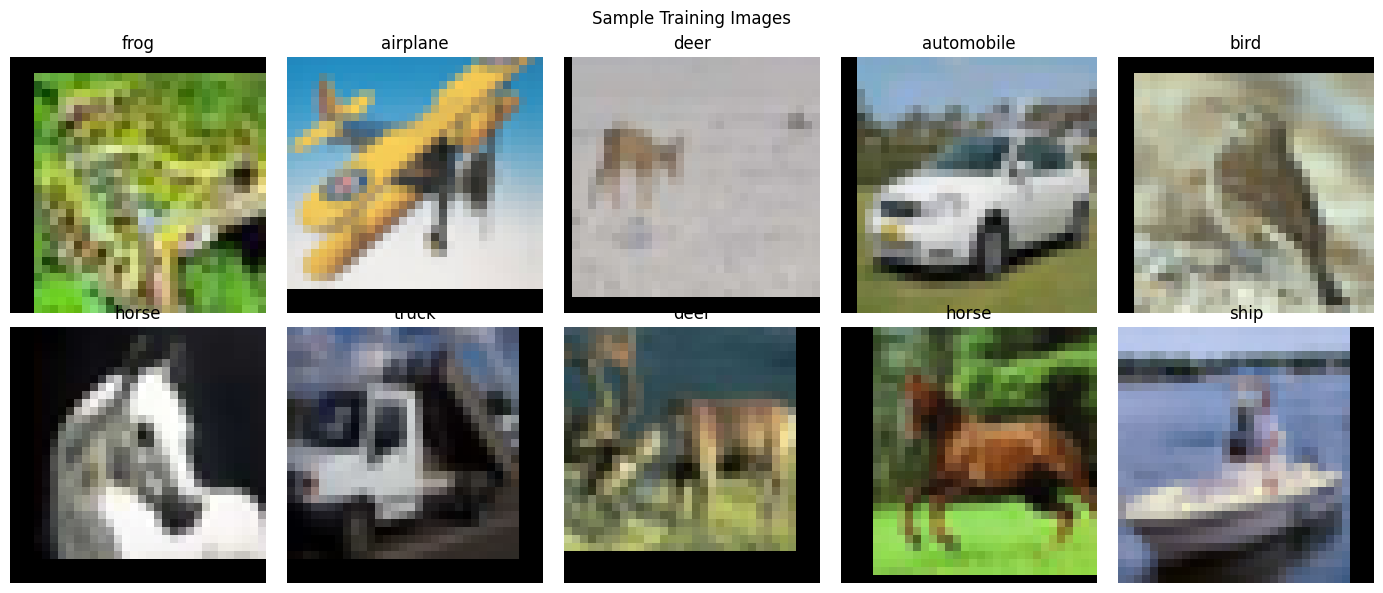

In [5]:
# Quick sanity check visualization
inv_mean = torch.tensor(mean).view(3, 1, 1)
inv_std = torch.tensor(std).view(3, 1, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for i in range(10):
    img = images[i].cpu() * inv_std + inv_mean
    img = torch.clamp(img, 0, 1)
    axes[i].imshow(img.permute(1, 2, 0).numpy())
    axes[i].set_title(class_names[labels[i].item()])
    axes[i].axis("off")

plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()

## CNN Architecture (PyTorch Style)

The structure mirrors the assignment style: reusable ConvBlock, stacked stages, ReLU activations, and clear forward flow.

In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


class CAMCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CAMCNN, self).__init__()

        # Input: 3x32x32
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        self.block1 = ConvBlock(64, 128, stride=2)   # -> 128x16x16
        self.block2 = ConvBlock(128, 256, stride=2)  # -> 256x8x8
        self.block3 = ConvBlock(256, 256, stride=1)  # -> 256x8x8

        # CAM-compatible head
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x, return_features=False):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        features = self.block3(x)

        pooled = self.gap(features)
        pooled = torch.flatten(pooled, 1)
        logits = self.fc(pooled)

        if return_features:
            return logits, features
        return logits

In [7]:
model = CAMCNN(num_classes=10).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"Trainable parameters: {num_params:,}")

CAMCNN(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (block1): ConvBlock(
    (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
  )
  (block2): ConvBlock(
    (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
  )
  (block3): ConvBlock(
    (conv): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
  )
  (gap): AdaptiveAvgPool2d(output_size=(1

C:\Users\shamb\AppData\Local\Temp\ipykernel_2896\895590442.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


## Training and Evaluation

These defaults are tuned for your local hardware (12 GB GPU): larger batch size, mixed precision, and enough epochs for a meaningful sample solution without very long runtime.

In [8]:
EPOCHS = 12

train_losses = []
train_accs = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}", leave=False)
    for images, labels in pbar:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{(correct / total) * 100:.2f}%"
        })

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    print(f"Epoch {epoch + 1:02d} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc * 100:.2f}%")

Epoch 1/12:   0%|          | 0/196 [00:00<?, ?it/s]

C:\Users\shamb\AppData\Local\Temp\ipykernel_2896\3605411524.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 01 | Train Loss: 1.5561 | Train Acc: 44.17%


Epoch 2/12:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 02 | Train Loss: 1.2223 | Train Acc: 56.97%


...

Epoch 10 | Train Loss: 0.7256 | Train Acc: 74.98%


Epoch 11/12:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 11 | Train Loss: 0.7007 | Train Acc: 75.83%


Epoch 12/12:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 12 | Train Loss: 0.6784 | Train Acc: 76.39%


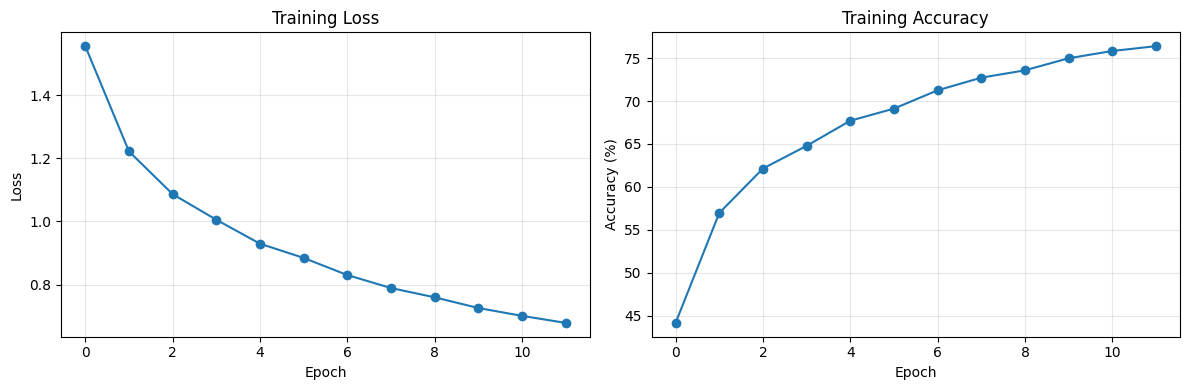

In [9]:
# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot([x * 100 for x in train_accs], marker="o")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Test evaluation
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        logits = model(images)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Testing:   0%|          | 0/40 [00:00<?, ?it/s]

Test Accuracy: 72.12%


## CAM Utilities and Visualization

In [11]:
def denormalize(img_tensor, mean, std):
    mean_t = torch.tensor(mean, device=img_tensor.device).view(3, 1, 1)
    std_t = torch.tensor(std, device=img_tensor.device).view(3, 1, 1)
    out = img_tensor * std_t + mean_t
    return torch.clamp(out, 0, 1)


def generate_cam(model, input_tensor, class_idx=None):
    model.eval()

    with torch.no_grad():
        logits, feature_maps = model(input_tensor, return_features=True)
        probs = torch.softmax(logits, dim=1)

        if class_idx is None:
            class_idx = int(torch.argmax(logits, dim=1).item())

        # CAM = weighted sum of last conv feature maps using classifier weights
        weights = model.fc.weight[class_idx]  # [channels]
        cam = torch.einsum("c,chw->hw", weights, feature_maps.squeeze(0))
        cam = torch.relu(cam)

        cam_min, cam_max = cam.min(), cam.max()
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

    return cam.detach().cpu().numpy(), probs.squeeze(0).detach().cpu().numpy(), class_idx


def cam_overlay(image_tensor, cam_map, alpha=0.45):
    # image_tensor: [3, H, W], values in [0, 1]
    img = image_tensor.detach().cpu().permute(1, 2, 0).numpy()

    cam_t = torch.tensor(cam_map, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    cam_up = torch.nn.functional.interpolate(
        cam_t,
        size=(img.shape[0], img.shape[1]),
        mode="bilinear",
        align_corners=False,
    ).squeeze().numpy()

    heatmap = plt.cm.jet(cam_up)[..., :3]
    overlay = (1 - alpha) * img + alpha * heatmap
    overlay = np.clip(overlay, 0, 1)

    return overlay, cam_up

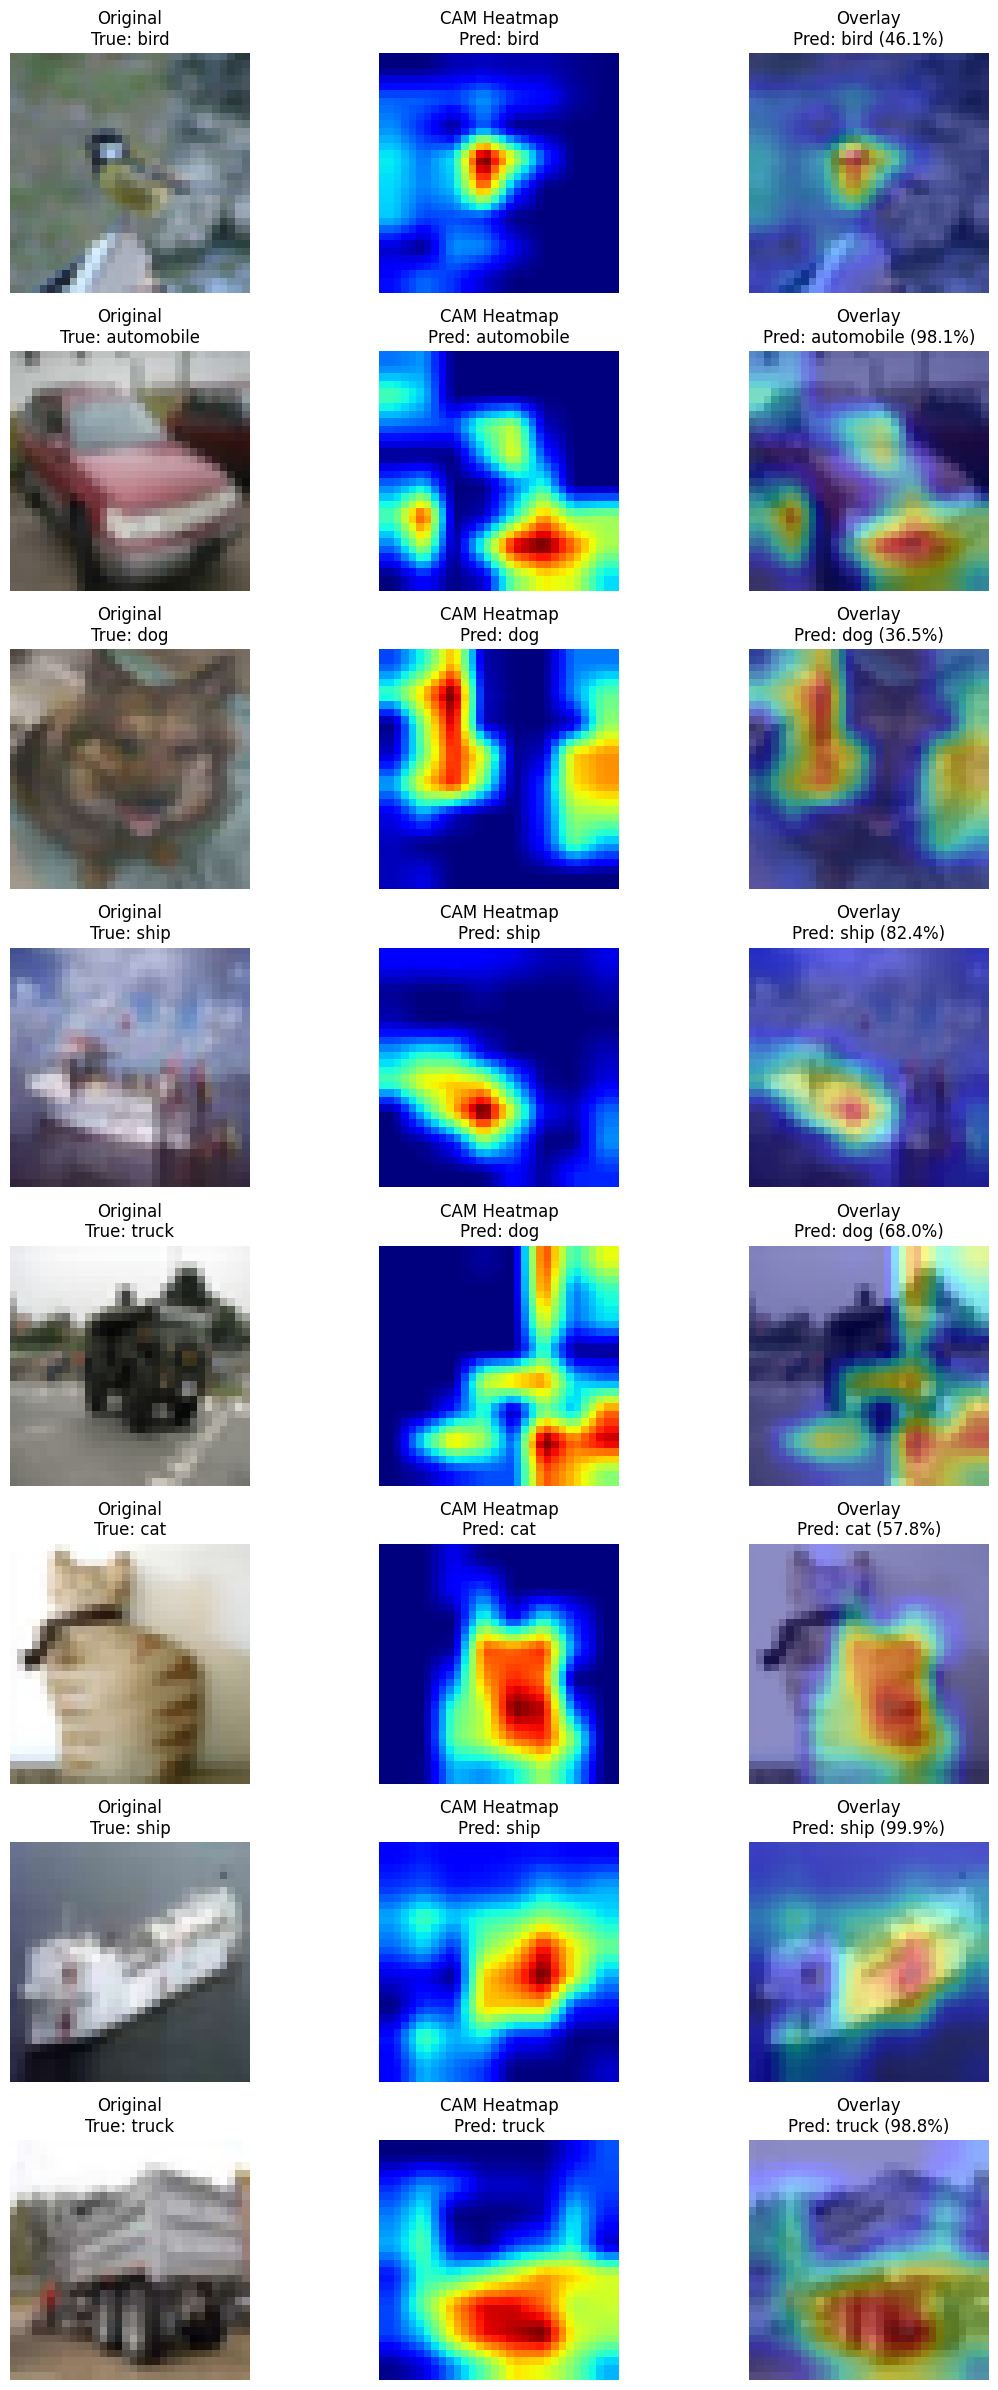

In [12]:
# Show CAM overlays on sample test images
num_samples = 8
sample_indices = np.random.choice(len(test_dataset), size=num_samples, replace=False)

fig, axes = plt.subplots(num_samples, 3, figsize=(12, 3 * num_samples))
if num_samples == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(sample_indices):
    img, true_label = test_dataset[idx]
    input_tensor = img.unsqueeze(0).to(DEVICE)

    cam_map, probs, pred_idx = generate_cam(model, input_tensor)

    denorm_img = denormalize(img.to(DEVICE), mean, std).cpu()
    overlay, cam_up = cam_overlay(denorm_img, cam_map, alpha=0.45)

    axes[row, 0].imshow(denorm_img.permute(1, 2, 0).numpy())
    axes[row, 0].set_title(f"Original\nTrue: {class_names[true_label]}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(cam_up, cmap="jet")
    axes[row, 1].set_title(f"CAM Heatmap\nPred: {class_names[pred_idx]}")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(
        f"Overlay\nPred: {class_names[pred_idx]} ({probs[pred_idx] * 100:.1f}%)"
    )
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

In [13]:
# Optional: save model checkpoint
checkpoint_path = Path("./runtime_data") / "cam_cnn_cifar10.pth"
torch.save(model.state_dict(), checkpoint_path)
print(f"Model saved to: {checkpoint_path.resolve()}")

Model saved to: F:\PhD Stuff\DL Lab\CAMs\runtime_data\cam_cnn_cifar10.pth
